In [1]:
# ====== 1. Imports + config + helpers ======
import os
import glob
import random
import pandas as pd
import numpy as np
import xml.etree.ElementTree as ET
from PIL import Image
from tqdm.notebook import tqdm

# ---------------- CONFIG ----------------
# Root directory containing your job_* folders (unchanged)
SOURCE_ROOT = os.path.join(".", "unmasked")

# Output CSV (unchanged)
OUTPUT_CSV = "labels_masked_inplace.csv"

# Reproducibility
SEED = 42

# Data splits (unchanged)
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
# Remaining 15% is test

# ------------- CLASS MAPPING -------------
CLASS_MAP = {
    "A2C": "A2C", "A3C": "A3C", "A4C": "A4C", "A5C": "A5C",
    "PLAX": "PLAX", "SSN": "SSN",
    "PSAX-AV": "PSAX-AV", "PSAX-PM": "PSAX-PM",
    "PSAX-MV": "PSAX-MV", "PSAX-AP": "PSAX-AP",
    "Subcostal": "Subcostal", "SBC-4C": "Subcostal",
    "SBC-Vessel": "Subcostal", "SBC-SA": "Subcostal",
    "TEE": "TEE",
    "Exclude": "Exclude",
    # any other labels not listed here will be skipped
}

def map_label(raw_label):
    return CLASS_MAP.get(raw_label, None)

# ------------- CLEANUP OLD MASKS -------------
def cleanup_old_masks(root_dir):
    print(f"Scanning {root_dir} for old masked images to delete...")
    old_masks = glob.glob(os.path.join(root_dir, "**", "*_masked.jpg"),
                          recursive=True)
    if old_masks:
        print(f"Found {len(old_masks)} old masked images. Deleting...")
        for f in tqdm(old_masks, desc="Deleting old masks"):
            try:
                os.remove(f)
            except OSError as e:
                print(f"Error deleting {f}: {e}")
        print("Cleanup complete.")
    else:
        print("No old masked images found. Clean start.")

cleanup_old_masks(SOURCE_ROOT)

# ------------- SECTOR MASK -------------
def apply_mask(img_array):
    """
    Applies the 'Voxel Cone' sector mask.
    Expects RGB input (H, W, 3).
    """
    h, w = img_array.shape[:2]
    mask = np.ones((h, w), dtype=np.uint8)

    def draw_box(x, y, box_w, box_h):
        x1, y1 = max(0, int(x)), max(0, int(y))
        x2, y2 = min(w, int(x + box_w)), min(h, int(y + box_h))
        mask[y1:y2, x1:x2] = 0

    # 1. Top & Bottom bars
    draw_box(0, 0, w, h * (35/480))
    draw_box(0, h - h*(90/480), w, h * (120/480))

    # 2. Left-side stack
    draw_box(0, 0, w*(60/640), h)
    draw_box(0, 0, w*(90/640), h*0.55)
    draw_box(0, 0, w*(77/640), h*0.62)
    draw_box(0, 0, w*(130/640), h*0.3)
    draw_box(0, 0, w*(150/640), h*0.26)
    draw_box(0, 0, w*(220/640), h*0.20)
    draw_box(0, h*0.72, w*(105/640), h*0.3)

    # 3. Right-side stack
    draw_box(w - w*(220/640), 0, w*(220/640), h*0.20)
    draw_box(w - w*(145/640), 0, w*(120/640), h*0.49)
    draw_box(w - w*(130/640), 0, w*(120/640), h*0.51)
    draw_box(w - w*(115/640), 0, w*(120/640), h*0.53)
    draw_box(w - w*(90/640), 0, w*(120/640), h)
    draw_box(w - w*(105/640), h*0.68, w*(105/640), h*0.3)
    draw_box(w - w*(115/640), h*0.72, w*(105/640), h*0.3)

    if img_array.ndim == 3:
        return img_array * mask[:, :, None]
    else:
        return img_array * mask

# ------------- SINGLE-IMAGE MASKING -------------
def mask_image(source_path):
    """
    Given an original JPG path, create the corresponding _masked.jpg
    if it does not already exist, and return the masked path.
    """
    base, ext = os.path.splitext(source_path)
    masked_path = f"{base}_masked{ext}"

    if os.path.exists(masked_path):
        return masked_path

    with Image.open(source_path) as img:
        img = img.convert("RGB")
        img_arr = np.array(img)
        masked_arr = apply_mask(img_arr)
        Image.fromarray(masked_arr).save(masked_path)

    return masked_path

Scanning ./unmasked for old masked images to delete...
No old masked images found. Clean start.


In [2]:
# ====== 2. Parse XML + generate masked images + CSV rows ======

def parse_annotations(xml_path, job_id, job_folder_path):
    if not os.path.exists(xml_path):
        return []

    tree = ET.parse(xml_path)
    root = tree.getroot()
    extracted_data = []

    for image in root.findall('image'):
        rel_path = image.get('name')

        # Locate original file
        full_source_path = os.path.join(job_folder_path, "images", rel_path)
        if not os.path.exists(full_source_path):
            full_source_path = os.path.join(job_folder_path, rel_path)
            if not os.path.exists(full_source_path):
                continue

        target_label = None
        
        for tag in image.findall('tag'):
            tag_label = tag.get('label')  # This gets "TTE", "TEE", or "Exclude"

            if tag_label == 'TTE':
                # Look for the specific View attribute for TTE
                for attr in tag.findall('attribute'):
                    if attr.get('name') == 'View':
                        target_label = map_label(attr.text)
                        break
            
            elif tag_label in ['TEE', 'Exclude']:
                # For TEE and Exclude, the label itself is the target
                target_label = map_label(tag_label)

            if target_label:
                break # Stop looking once we find a valid label

        if target_label:
            extracted_data.append({
                "source_path": full_source_path,
                "label": target_label,
                "job_id": job_id,
            })

    return extracted_data


# --- Gather annotated source files (unchanged behaviour) ---
print("Parsing XML annotations...")
all_source_files = []
job_folders = sorted(glob.glob(os.path.join(SOURCE_ROOT, "job_*")))

for job_folder in tqdm(job_folders, desc="Scanning jobs"):
    job_id = job_folder.split("_")[-1]
    xml_file = os.path.join(job_folder, "annotations.xml")
    all_source_files.extend(parse_annotations(xml_file, job_id, job_folder))

print(f"Found {len(all_source_files)} valid annotated images.")

# --- Mask annotated images and build CSV rows (unchanged semantics) ---
final_csv_data = []
print("Generating RGB masked images for annotated files...")

for item in tqdm(all_source_files, desc="Masking annotated"):
    try:
        masked_path = mask_image(item["source_path"])
        final_csv_data.append({
            "filename": masked_path,
            "label": item["label"],
            "job_id": item["job_id"],
        })
    except Exception as e:
        print(f"Error processing {item['source_path']}: {e}")

print(f"Done! Created/verified {len(final_csv_data)} masked images for annotated files.")

# --- NEW: ensure *all* JPGs in SOURCE_ROOT have a _masked copy ---
print("\nEnsuring all JPGs under SOURCE_ROOT have a corresponding _masked.jpg...")
all_jpgs = glob.glob(os.path.join(SOURCE_ROOT, "**", "*.jpg"), recursive=True)

to_process = [p for p in all_jpgs if not p.endswith("_masked.jpg")]
print(f"Found {len(to_process)} original JPGs (excluding existing _masked).")

for p in tqdm(to_process, desc="Masking all JPGs"):
    try:
        mask_image(p)
    except Exception as e:
        print(f"Error masking {p}: {e}")

print("All JPGs now have corresponding _masked.jpg files.")

Parsing XML annotations...


Scanning jobs:   0%|          | 0/70 [00:00<?, ?it/s]

Found 27227 valid annotated images.
Generating RGB masked images for annotated files...


Masking annotated:   0%|          | 0/27227 [00:00<?, ?it/s]

Done! Created/verified 27227 masked images for annotated files.

Ensuring all JPGs under SOURCE_ROOT have a corresponding _masked.jpg...
Found 34764 original JPGs (excluding existing _masked).


Masking all JPGs:   0%|          | 0/34764 [00:00<?, ?it/s]

All JPGs now have corresponding _masked.jpg files.


In [3]:
# ====== 3. Train/val/test split by job_id + save CSV ======

# 1. Unique jobs
unique_jobs = sorted(set(x["job_id"] for x in final_csv_data))
random.seed(SEED)
random.shuffle(unique_jobs)

# 2. Calculate job-level splits
n_jobs = len(unique_jobs)
n_train = int(n_jobs * TRAIN_RATIO)
n_val = int(n_jobs * VAL_RATIO)

train_jobs = set(unique_jobs[:n_train])
val_jobs = set(unique_jobs[n_train:n_train + n_val])
# remaining jobs -> test

# 3. Assign split to each row
for row in final_csv_data:
    if row["job_id"] in train_jobs:
        row["split"] = "train"
    elif row["job_id"] in val_jobs:
        row["split"] = "val"
    else:
        row["split"] = "test"

# 4. Save CSV
df = pd.DataFrame(final_csv_data)
df.to_csv(OUTPUT_CSV, index=False)

print(f"Success! Labels saved to {OUTPUT_CSV}")
print("-" * 30)
print(df["split"].value_counts())
print("-" * 30)
print("Example filename:", df.iloc[0]["filename"])

Success! Labels saved to labels_masked_inplace.csv
------------------------------
split
train    19160
test      4309
val       3758
Name: count, dtype: int64
------------------------------
Example filename: ./unmasked/job_1734/images/h4h_ef_frames/1.2.276.0.7230010.3.1.2.845494328.1.1703598471.21532689/1.2.276.0.7230010.3.1.3.845494328.1.1703598471.21532690/mp4/1.2.276.0.7230010.3.1.4.1714578744.1.1703600527.15739402_masked.jpg



--- Final masking verification ---


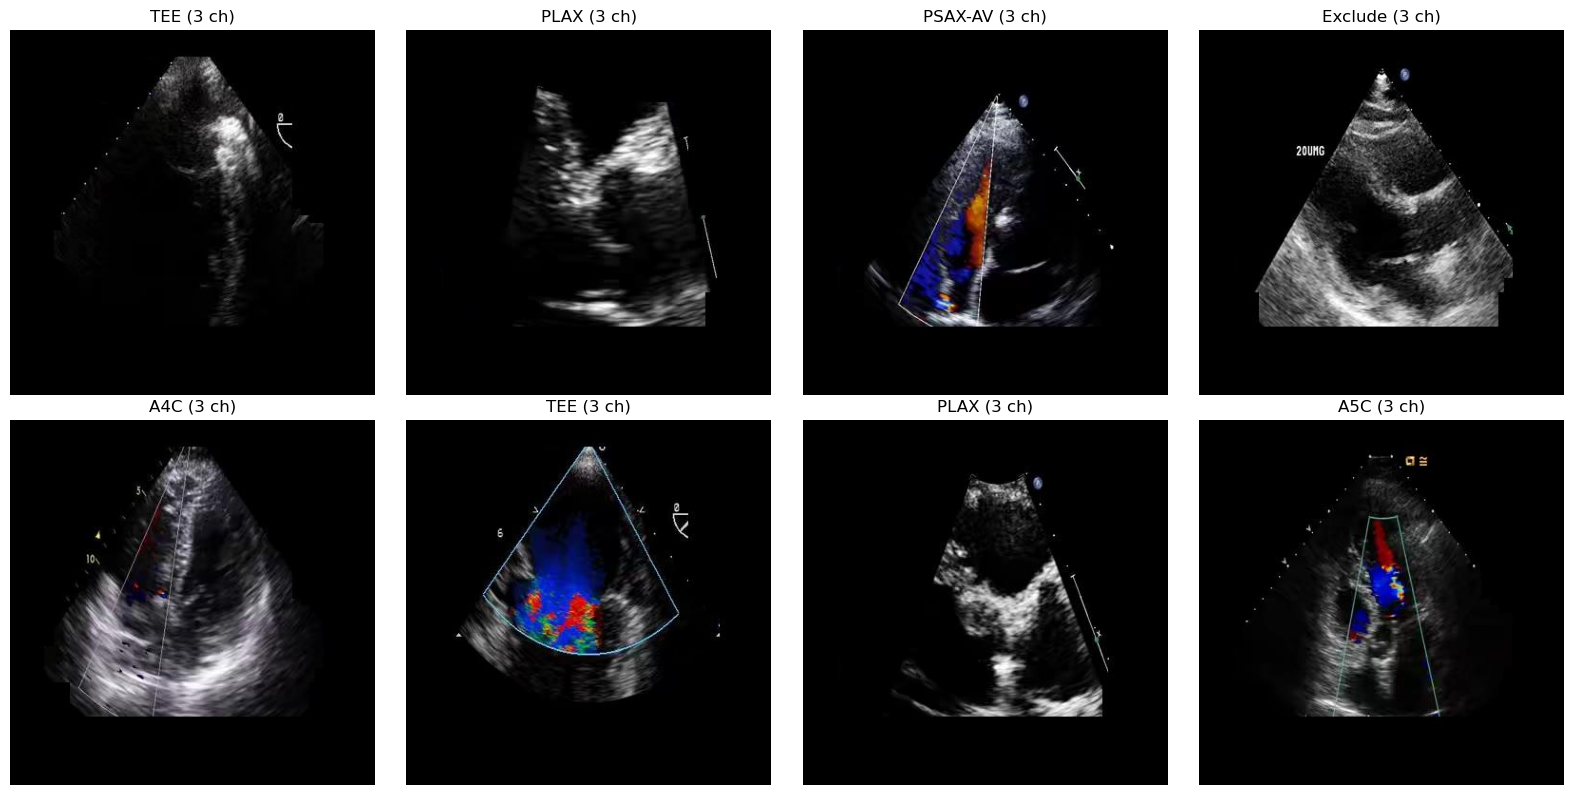

Masking visualization complete.


In [4]:
# ====== 4. Quick visual check of masked images ======
import matplotlib.pyplot as plt

OUTPUT_CSV = "labels_masked_inplace.csv"
NUM_TO_VISUALIZE = 8

print("\n--- Final masking verification ---")

if not os.path.exists(OUTPUT_CSV):
    print(f"Error: Final CSV '{OUTPUT_CSV}' not found.")
else:
    df = pd.read_csv(OUTPUT_CSV)

    if len(df) <= NUM_TO_VISUALIZE:
        sample_df = df
        print(f"Only {len(df)} rows in CSV. Displaying all.")
    else:
        # different random subset each time
        sample_df = df.sample(n=NUM_TO_VISUALIZE)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    for i, (_, row) in enumerate(sample_df.iterrows()):
        img_path = row["filename"]
        label = row["label"]

        try:
            img = Image.open(img_path)
            img_data = np.array(img)

            cmap = "gray" if img_data.ndim == 2 else None
            axes[i].imshow(img_data, cmap=cmap)
            ch = img_data.shape[2] if img_data.ndim == 3 else 1
            axes[i].set_title(f"{label} ({ch} ch)")
            axes[i].axis("off")
        except Exception as e:
            axes[i].set_title("Load error")
            axes[i].axis("off")
            print(f"Could not load image {img_path}: {e}")

    for j in range(len(sample_df), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()
    print("Masking visualization complete.")


# IMPORTANT: IGNORE SPLITS HERE

Counts by label and split:


split,test,train,val
label,,,
A2C,361,1622,276
A3C,267,1312,234
A4C,843,3835,655
A5C,168,815,151
Exclude,393,1884,286
PLAX,659,3028,478
PSAX-AP,71,360,53
PSAX-AV,368,1856,329
PSAX-MV,80,398,80



Row-normalized (percentage within each split):


split,test,train,val
label,,,
A2C,8.38,8.47,7.34
A3C,6.20,6.85,6.23
A4C,19.56,20.02,17.43
A5C,3.90,4.25,4.02
Exclude,9.12,9.83,7.61
PLAX,15.29,15.80,12.72
PSAX-AP,1.65,1.88,1.41
PSAX-AV,8.54,9.69,8.75
PSAX-MV,1.86,2.08,2.13


<Figure size 1200x600 with 0 Axes>

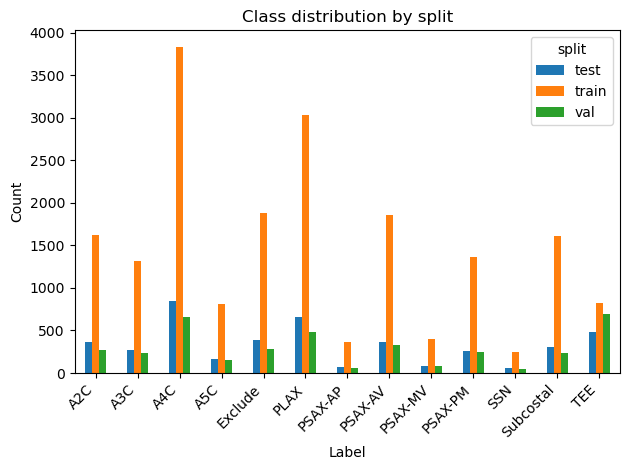

<Figure size 1200x600 with 0 Axes>

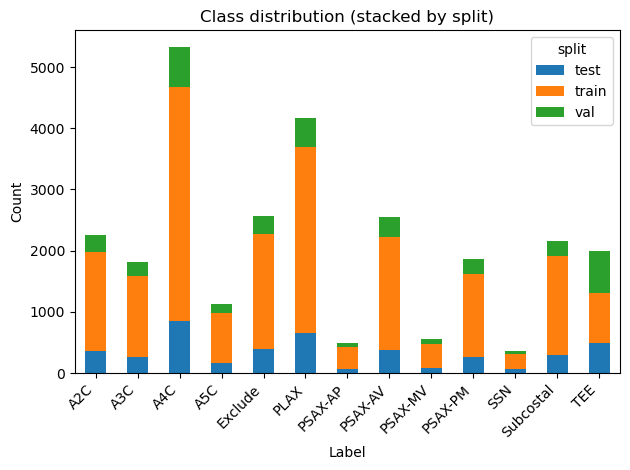

In [5]:
# ====== Class distribution across splits ======
import matplotlib.pyplot as plt

OUTPUT_CSV = "labels_masked_inplace.csv"

df = pd.read_csv(OUTPUT_CSV)

# Raw counts by split + label
print("Counts by label and split:")
counts = pd.crosstab(df["label"], df["split"])
display(counts)

# Percentage within each split
print("\nRow-normalized (percentage within each split):")
percent = counts.div(counts.sum(axis=0), axis=1) * 100
display(percent.round(2))

# --- Bar plot: counts per class per split ---
plt.figure(figsize=(12, 6))
counts.plot(kind="bar")
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Class distribution by split")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# --- Optional: stacked bar of split composition per class ---
plt.figure(figsize=(12, 6))
counts.plot(kind="bar", stacked=True)
plt.xlabel("Label")
plt.ylabel("Count")
plt.title("Class distribution (stacked by split)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [8]:
import pandas as pd

p = "labels_patient_split_mp4.csv"
df = pd.read_csv(p)

# Your header has duplicate "split". Rename duplicates to make them selectable.
cols = []
seen = {}
for c in df.columns:
    k = c
    if k in seen:
        seen[k] += 1
        k = f"{c}_{seen[c]}"
    else:
        seen[k] = 0
    cols.append(k)
df.columns = cols

# pick the first split column (usually the one you want)
split_col = "split" if "split" in df.columns else [c for c in df.columns if c.startswith("split")][0]

counts = (
    df.groupby([split_col, "label"])
      .size()
      .rename("count")
      .reset_index()
      .sort_values([split_col, "count"], ascending=[True, False])
)

# add per-split percentages
counts["pct_within_split"] = counts["count"] / counts.groupby(split_col)["count"].transform("sum") * 100

print("Columns:", list(df.columns))
print("\nCounts:")
print(counts.to_string(index=False))

print("\nTotals per split:")
print(df.groupby(split_col).size().rename("total").to_string())

Columns: ['filename', 'label', 'job_id', 'split', 'study_id', 'patient_id', 'split.1', 'mp4_path']

Counts:
split     label  count  pct_within_split
 test       A4C    554         19.596746
 test      PLAX    442         15.634949
 test   PSAX-AV    270          9.550761
 test   Exclude    255          9.020163
 test       A2C    239          8.454192
 test Subcostal    235          8.312699
 test   PSAX-PM    191          6.756279
 test       A3C    189          6.685532
 test       TEE    185          6.544040
 test       A5C    120          4.244782
 test   PSAX-MV     53          1.874779
 test   PSAX-AP     49          1.733286
 test       SSN     45          1.591793
train       A4C   4199         19.621495
train      PLAX   3252         15.196262
train   Exclude   2027          9.471963
train   PSAX-AV   2003          9.359813
train       A2C   1781          8.322430
train Subcostal   1668          7.794393
train       TEE   1613          7.537383
train   PSAX-PM   1460         

# Check Split File

In [6]:
import csv
from pathlib import Path
from typing import Optional, Tuple

# ==========================================
# 1. CONFIGURATION (Replaces command line args)
# ==========================================
IN_CSV = "labels_patient_split.csv"        # Path to your input CSV
OUT_CSV = "labels_patient_split_mp4.csv"   # Path to output CSV
ROOT_DIR = "/cluster/projects/bwanggroup/echo_reports/uhn_studies_22k_607_224px/" # Root of MP4s
CHECK_EXISTS = False                        # Set to True to verify file existence on disk
DROP_MISSING = False                        # Set to True to remove rows where MP4 is missing

# Key string to look for in the path to identify study/series
KEY = "h4h_ef_frames/"

# ==========================================
# 2. HELPER FUNCTIONS
# ==========================================
def extract_ids(p: str) -> Tuple[Optional[str], Optional[str], Optional[str]]:
    """Returns (study_id, series_id, filename) from a path containing .../h4h_ef_frames/<study>/<series>/..."""
    i = p.find(KEY)
    if i == -1:
        return None, None, None
    rest = p[i + len(KEY):]
    parts = rest.split("/")
    if len(parts) < 3:
        return None, None, None
    return parts[0], parts[1], parts[-1]

def jpg_to_sop_uid(fname: str) -> Optional[str]:
    if fname.endswith("_masked.jpg"):
        return fname[:-len("_masked.jpg")]
    if fname.endswith(".jpg"):
        return fname[:-len(".jpg")]
    return None

def jpg_to_mp4_path(jpg_path: str, root: Path) -> Optional[Path]:
    study_id, series_id, fname = extract_ids(jpg_path)
    if not study_id or not series_id or not fname:
        return None
    sop = jpg_to_sop_uid(fname)
    if not sop:
        return None
    return root / study_id / series_id / f"{sop}.mp4"

# ==========================================
# 3. MAIN EXECUTION LOGIC
# ==========================================

# Setup paths
in_csv_path = Path(IN_CSV)
out_csv_path = Path(OUT_CSV)
root_path = Path(ROOT_DIR).expanduser().resolve()

# Validation
if DROP_MISSING and not CHECK_EXISTS:
    raise ValueError("DROP_MISSING requires CHECK_EXISTS to be True.")

if not in_csv_path.exists():
    raise FileNotFoundError(f"Input CSV not found: {in_csv_path}")

out_csv_path.parent.mkdir(parents=True, exist_ok=True)

# Counters
exists = 0
missing = 0
unparsable = 0
total = 0
kept = 0
dropped = 0

print(f"Processing {IN_CSV}...")
print(f"Root dir: {root_path}")

with in_csv_path.open("r", newline="", encoding="utf-8") as f_in:
    r = csv.DictReader(f_in)
    if not r.fieldnames:
        raise ValueError("Input CSV has no header/fieldnames")

    fieldnames = list(r.fieldnames)
    out_fields = fieldnames + (["mp4_path"] if "mp4_path" not in fieldnames else [])

    with out_csv_path.open("w", newline="", encoding="utf-8") as f_out:
        w = csv.DictWriter(f_out, fieldnames=out_fields)
        w.writeheader()

        for row in r:
            total += 1
            jpg = (row.get("filename") or "").strip()
            mp4 = jpg_to_mp4_path(jpg, root_path)

            # Handle unparsable paths
            if mp4 is None:
                row["mp4_path"] = ""
                unparsable += 1
                if DROP_MISSING:
                    dropped += 1
                    continue
                w.writerow(row)
                kept += 1
                continue

            row["mp4_path"] = str(mp4)

            # Check existence if requested
            if CHECK_EXISTS:
                if mp4.exists():
                    exists += 1
                    w.writerow(row)
                    kept += 1
                else:
                    missing += 1
                    if DROP_MISSING:
                        dropped += 1
                        continue
                    w.writerow(row)
                    kept += 1
            else:
                w.writerow(row)
                kept += 1

# ==========================================
# 4. REPORT
# ==========================================
print("-" * 30)
print(f"Done! Wrote: {out_csv_path}")
print(f"Total input rows: {total}")
print(f"Kept rows:        {kept}")
if DROP_MISSING:
    print(f"Dropped rows:     {dropped} (missing or unparsable)")
print(f"Unparsable rows:  {unparsable}")
if CHECK_EXISTS:
    print(f"MP4 exists:       {exists}")
    print(f"MP4 missing:      {missing}")
print("-" * 30)

Processing labels_patient_split.csv...
Root dir: /cluster/projects/bwanggroup/echo_reports/uhn_studies_22k_607_224px
------------------------------
Done! Wrote: labels_patient_split_mp4.csv
Total input rows: 27227
Kept rows:        27227
Unparsable rows:  0
------------------------------


In [7]:
import pandas as pd

# Load the CSV we just created
df = pd.read_csv("labels_patient_split_mp4.csv")

# Set display options to see long S3/File paths clearly
pd.set_option('display.max_colwidth', None)

# Print the first 5 rows
print(f"Total rows in dataframe: {len(df)}")
df.head()

Total rows in dataframe: 27227


,filename,label,job_id,split,study_id,patient_id,split.1,mp4_path
0,./unmasked/job_1734/images/h4h_ef_frames/1.2.276.0.7230010.3.1.2.845494328.1.1703598471.21532689/1.2.276.0.7230010.3.1.3.845494328.1.1703598471.21532690/mp4/1.2.276.0.7230010.3.1.4.1714578744.1.1703600527.15739402_masked.jpg,Subcostal,1734,val,1.2.276.0.7230010.3.1.2.845494328.1.1703598471.21532689,3246838,val,/cluster/projects/bwanggroup/echo_reports/uhn_studies_22k_607_224px/1.2.276.0.7230010.3.1.2.845494328.1.1703598471.21532689/1.2.276.0.7230010.3.1.3.845494328.1.1703598471.21532690/1.2.276.0.7230010.3.1.4.1714578744.1.1703600527.15739402.mp4
1,./unmasked/job_1734/images/h4h_ef_frames/1.2.276.0.7230010.3.1.2.845494328.1.1703598471.21532689/1.2.276.0.7230010.3.1.3.845494328.1.1703598471.21532690/mp4/1.2.276.0.7230010.3.1.4.1714578744.1.1703600664.15740542_masked.jpg,Subcostal,1734,val,1.2.276.0.7230010.3.1.2.845494328.1.1703598471.21532689,3246838,val,/cluster/projects/bwanggroup/echo_reports/uhn_studies_22k_607_224px/1.2.276.0.7230010.3.1.2.845494328.1.1703598471.21532689/1.2.276.0.7230010.3.1.3.845494328.1.1703598471.21532690/1.2.276.0.7230010.3.1.4.1714578744.1.1703600664.15740542.mp4
2,./unmasked/job_1734/images/h4h_ef_frames/1.2.276.0.7230010.3.1.2.845494328.1.1703598471.21532689/1.2.276.0.7230010.3.1.3.845494328.1.1703598471.21532690/mp4/1.2.276.0.7230010.3.1.4.811753780.1.1703598679.15799699_masked.jpg,A4C,1734,val,1.2.276.0.7230010.3.1.2.845494328.1.1703598471.21532689,3246838,val,/cluster/projects/bwanggroup/echo_reports/uhn_studies_22k_607_224px/1.2.276.0.7230010.3.1.2.845494328.1.1703598471.21532689/1.2.276.0.7230010.3.1.3.845494328.1.1703598471.21532690/1.2.276.0.7230010.3.1.4.811753780.1.1703598679.15799699.mp4
3,./unmasked/job_1734/images/h4h_ef_frames/1.2.276.0.7230010.3.1.2.845494328.1.1703598471.21532689/1.2.276.0.7230010.3.1.3.845494328.1.1703598471.21532690/mp4/1.2.276.0.7230010.3.1.4.811753780.1.1703600397.15813507_masked.jpg,A2C,1734,val,1.2.276.0.7230010.3.1.2.845494328.1.1703598471.21532689,3246838,val,/cluster/projects/bwanggroup/echo_reports/uhn_studies_22k_607_224px/1.2.276.0.7230010.3.1.2.845494328.1.1703598471.21532689/1.2.276.0.7230010.3.1.3.845494328.1.1703598471.21532690/1.2.276.0.7230010.3.1.4.811753780.1.1703600397.15813507.mp4
4,./unmasked/job_1734/images/h4h_ef_frames/1.2.276.0.7230010.3.1.2.845494328.1.1703598471.21532689/1.2.276.0.7230010.3.1.3.845494328.1.1703598471.21532690/mp4/1.2.276.0.7230010.3.1.4.845494328.1.1703598813.21535585_masked.jpg,A2C,1734,val,1.2.276.0.7230010.3.1.2.845494328.1.1703598471.21532689,3246838,val,/cluster/projects/bwanggroup/echo_reports/uhn_studies_22k_607_224px/1.2.276.0.7230010.3.1.2.845494328.1.1703598471.21532689/1.2.276.0.7230010.3.1.3.845494328.1.1703598471.21532690/1.2.276.0.7230010.3.1.4.845494328.1.1703598813.21535585.mp4


In [1]:
import csv
import os

# ==========================================
# 1. CONFIGURATION
# ==========================================
# Input/Output files
IN_FILE = "labels_patient_split_mp4.csv"
OUT_FILE = "labels_patient_split_mp4_s3.csv"

# S3 Path Config
# Note: Using the _224px prefix seen in your error logs
S3_PREFIX = "s3://echodata25/results/uhn_studies_22k_607"
ROOT_MARKER = "uhn_studies_22k_607"

# ==========================================
# 2. TRANSFORMATION LOGIC
# ==========================================
def to_s3_path(mp4_path: str, s3_prefix: str, root_marker: str) -> str:
    """
    Finds the root_marker in the local path and swaps the 
    prefix for the S3 URI.
    """
    if not mp4_path or not isinstance(mp4_path, str):
        return mp4_path

    # Standardize separators to forward slashes for S3
    p = mp4_path.replace("\\", "/")  
    
    # We look for the folder name in the cluster path
    marker = f"/{root_marker}/"
    idx = p.find(marker)
    
    if idx == -1:
        # Fallback check: marker at the very start
        if p.startswith(root_marker + "/"):
            suffix = p[len(root_marker)+1:]
        else:
            raise ValueError(f"Marker '{root_marker}' not found in: {mp4_path}")
    else:
        # Extract everything after /root_marker/
        suffix = p[idx + len(marker):] 

    # Combine with clean S3 prefix
    return f"{s3_prefix.rstrip('/')}/{suffix}"

# ==========================================
# 3. EXECUTION
# ==========================================
n_processed = 0

with open(IN_FILE, "r", newline="", encoding="utf-8") as fin:
    reader = csv.DictReader(fin)
    fieldnames = reader.fieldnames
    
    if "mp4_path" not in fieldnames:
        raise ValueError(f"Column 'mp4_path' not found. Available: {fieldnames}")

    with open(OUT_FILE, "w", newline="", encoding="utf-8") as fout:
        writer = csv.DictWriter(fout, fieldnames=fieldnames)
        writer.writeheader()

        for row in reader:
            try:
                row["mp4_path"] = to_s3_path(row["mp4_path"], S3_PREFIX, ROOT_MARKER)
                writer.writerow(row)
                n_processed += 1
            except ValueError as e:
                print(f"Skipping row due to error: {e}")

print(f"Successfully converted {n_processed} paths.")
print(f"New CSV saved to: {OUT_FILE}")

# ==========================================
# 4. VERIFY HEAD
# ==========================================
import pandas as pd
df_s3 = pd.read_csv(OUT_FILE)
df_s3[['label', 'split', 'mp4_path']].head()

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



Successfully converted 0 paths.
New CSV saved to: labels_patient_split_mp4_s3.csv


,label,split,mp4_path


In [10]:
import pandas as pd
import boto3
from tqdm.notebook import tqdm
from urllib.parse import urlparse
from botocore.exceptions import ClientError

# ==========================================
# 1. CONFIGURATION
# ==========================================
IN_CSV = "labels_patient_split_mp4_s3.csv"
# IN_CSV = "labels_zoom_s3.csv"
NUM_SAMPLES = 1000
MP4_COL = "mp4_path"
OUT_PREFIX = "random_check"

# ==========================================
# 2. EXECUTION logic
# ==========================================
s3 = boto3.client('s3')

def check_exists(uri):
    u = urlparse(uri)
    bucket, key = u.netloc, u.path.lstrip("/")
    try:
        s3.head_object(Bucket=bucket, Key=key)
        return "Found"
    except ClientError as e:
        return "Missing" if e.response['Error']['Code'] == "404" else f"Error: {e}"

# Load data
df = pd.read_csv(IN_CSV)

# Random Sample (no random_state means it changes every run)
sample_df = df.sample(n=min(NUM_SAMPLES, len(df))).copy()

print(f"Checking {len(sample_df)} random files...")

# Run checks with progress bar
results = []
for uri in tqdm(sample_df[MP4_COL]):
    results.append(check_exists(uri))

sample_df['check_result'] = results

# Separate results
found = sample_df[sample_df['check_result'] == "Found"]
missing = sample_df[sample_df['check_result'] == "Missing"]
errors = sample_df[~sample_df['check_result'].isin(["Found", "Missing"])]

# Save to disk
sample_df.to_csv(f"{OUT_PREFIX}_results.csv", index=False)

# ==========================================
# 3. SUMMARY REPORT
# ==========================================
print("\n" + "="*40)
print(f"RANDOM CHECK SUMMARY")
print("="*40)
print(f"✅ Found:   {len(found)}")
print(f"❌ Missing: {len(missing)}")
print(f"⚠️ Errors:  {len(errors)}")
print("="*40)

if not missing.empty:
    print("\nFirst 3 Missing Paths:")
    print(missing[MP4_COL].head(3).to_list())
else:
    print("\nNo missing files found in this random batch! 🎉")

Checking 1000 random files...


  0%|          | 0/1000 [00:00<?, ?it/s]


RANDOM CHECK SUMMARY
✅ Found:   993
❌ Missing: 7
⚠️ Errors:  0

First 3 Missing Paths:
['s3://echodata25/results/uhn_studies_22k_607_224px/1.2.276.0.7230010.3.1.2.859333938.1.1703118659.8085732/1.2.276.0.7230010.3.1.3.859333938.1.1703118659.8085733/1.2.276.0.7230010.3.1.4.845494328.1.1703119515.13432400.mp4', 's3://echodata25/results/uhn_studies_22k_607_224px/1.2.276.0.7230010.3.1.2.859333938.1.1703725745.17057905/1.2.276.0.7230010.3.1.3.859333938.1.1703725745.17057906/1.2.276.0.7230010.3.1.4.811753780.1.1703726191.16977175.mp4', 's3://echodata25/results/uhn_studies_22k_607_224px/1.2.276.0.7230010.3.1.2.859333938.1.1703118659.8085732/1.2.276.0.7230010.3.1.3.859333938.1.1703118659.8085733/1.2.276.0.7230010.3.1.4.1714512485.1.1703119243.10448736.mp4']


# Color

In [2]:
import os
import glob
import pandas as pd
import xml.etree.ElementTree as ET
from tqdm.notebook import tqdm

# ---------------- CONFIG ----------------
SOURCE_ROOT = os.path.join(".", "unmasked")
REFERENCE_CSV = "labels_patient_split.csv" # The source of truth for splits

# ---------------- HELPERS ----------------
def map_quality(raw_val):
    if not raw_val: return None
    v = str(raw_val).lower()
    
    # --- BINARY MAPPING STRATEGY ---
    # Class 0 (Fail): Unusable/Poor. (Old "Low" + Scores 0, 1, 2)
    if 'low' in v or any(s in v for s in ['0', '1', '2']):
        return "discard"
        
    # Class 1 (Pass): Diagnostic/Good. (Old "Med" + "High" + Scores 3, 4, 5, 6)
    # Merging these eliminates the noise that caused your model collapse.
    if 'medium' in v or 'high' in v or any(s in v for s in ['3', '4', '5', '6']):
        return "keep"
        
    return None

def parse_all_tasks(xml_path, job_id, job_folder_path):
    if not os.path.exists(xml_path): return []
    tree = ET.parse(xml_path)
    root = tree.getroot()
    data = []

    for image in root.findall('image'):
        rel_path = image.get('name')
        base, ext = os.path.splitext(rel_path)
        masked_path = os.path.join(job_folder_path, f"{base}_masked{ext}")
        
        tag = image.find("tag[@label='TTE']")
        if tag is None: continue

        attrs = {attr.get('name'): attr.text for attr in tag.findall('attribute')}
        data.append({
            "filename": masked_path,
            "job_id": int(job_id), # Ensure job_id is int for matching
            "color": attrs.get('Color'),
            "zoom": attrs.get('Zoom'),
            "quality": map_quality(attrs.get('Quality'))
        })
    return data

# 1. Load the reference split mapping
print(f"Loading reference splits from {REFERENCE_CSV}...")
ref_df = pd.read_csv(REFERENCE_CSV)

# Ensure we have a clean mapping of job_id -> split
# (Handling the potential duplicate 'split' columns you mentioned earlier)
if 'split' not in ref_df.columns:
    split_col = [c for c in ref_df.columns if c.startswith('split')][0]
    ref_df = ref_df.rename(columns={split_col: 'split'})

split_map = ref_df[['job_id', 'split']].drop_duplicates().set_index('job_id')['split'].to_dict()

# 2. Gather all raw attribute data
all_data = []
job_folders = sorted(glob.glob(os.path.join(SOURCE_ROOT, "job_*")))
for folder in tqdm(job_folders, desc="Parsing XMLs"):
    jid = folder.split("_")[-1]
    all_data.extend(parse_all_tasks(os.path.join(folder, "annotations.xml"), jid, folder))

df_master = pd.DataFrame(all_data)

# 3. Apply the reference split to the master dataframe
df_master['split'] = df_master['job_id'].map(split_map)

# 4. Create individual CSVs
tasks = {
    "color": "labels_color.csv",
    "zoom": "labels_zoom.csv",
    "quality": "labels_quality.csv"
}

print("\n--- Generation Summary ---")
for task_key, filename in tasks.items():
    # Filter for valid rows, drop rows with no split mapping (if any), and format
    subset = df_master[df_master[task_key].notna() & df_master['split'].notna()].copy()
    subset = subset.rename(columns={task_key: "label"})
    subset = subset[["filename", "label", "job_id", "split"]]
    
    subset.to_csv(filename, index=False)
    
    print(f"\nSaved {filename} ({len(subset)} rows)")
    print(pd.crosstab(subset["label"], subset["split"]))

Loading reference splits from labels_patient_split.csv...


Parsing XMLs:   0%|          | 0/70 [00:00<?, ?it/s]


--- Generation Summary ---

Saved labels_color.csv (23116 rows)
split  test  train   val
label                   
No     4785   4576  5084
Yes    2731   2820  3120

Saved labels_zoom.csv (23116 rows)
split  test  train   val
label                   
Full   6136   5920  6376
Large  1213   1322  1619
Small   167    154   209

Saved labels_quality.csv (23111 rows)
split    test  train   val
label                     
discard  2413   2236  2442
keep     5102   5159  5759
